# micro
deep dive into each activity

In [1]:
import os
import numpy as np 
from astropy.table import Table

In [2]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
data_binary = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/data_binary_act.hdf5')
micro = data_binary[data_binary['arch'] == 'micro']
YX_micro = np.array([np.array(micro[col]) for col in micro.colnames[:-2]]).T

In [4]:
def dY_jackknife(dY, zipcodes, func=np.median, njack=5): 
    ''' jackknife uncertainties 
    '''
    mu_dY = func(dY)
    
    mu_dY_jack, n_jack = [], 0
    for i in range(njack): 
        in_jack = ((zipcodes % njack) == i)
        if np.sum(in_jack) == 0: continue
            
        mu_dY_jack.append(func(dY[~in_jack]))
        n_jack += 1
    if n_jack < 3: return np.inf
    
    mu_dY_jack = np.array(mu_dY_jack)
    
    sig_jack = np.sqrt((n_jack - 1)/n_jack * np.sum((mu_dY_jack - mu_dY)**2))
    return sig_jack

## examine natural experiments

### c360

In [5]:
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/micro.0_1.hdf5')

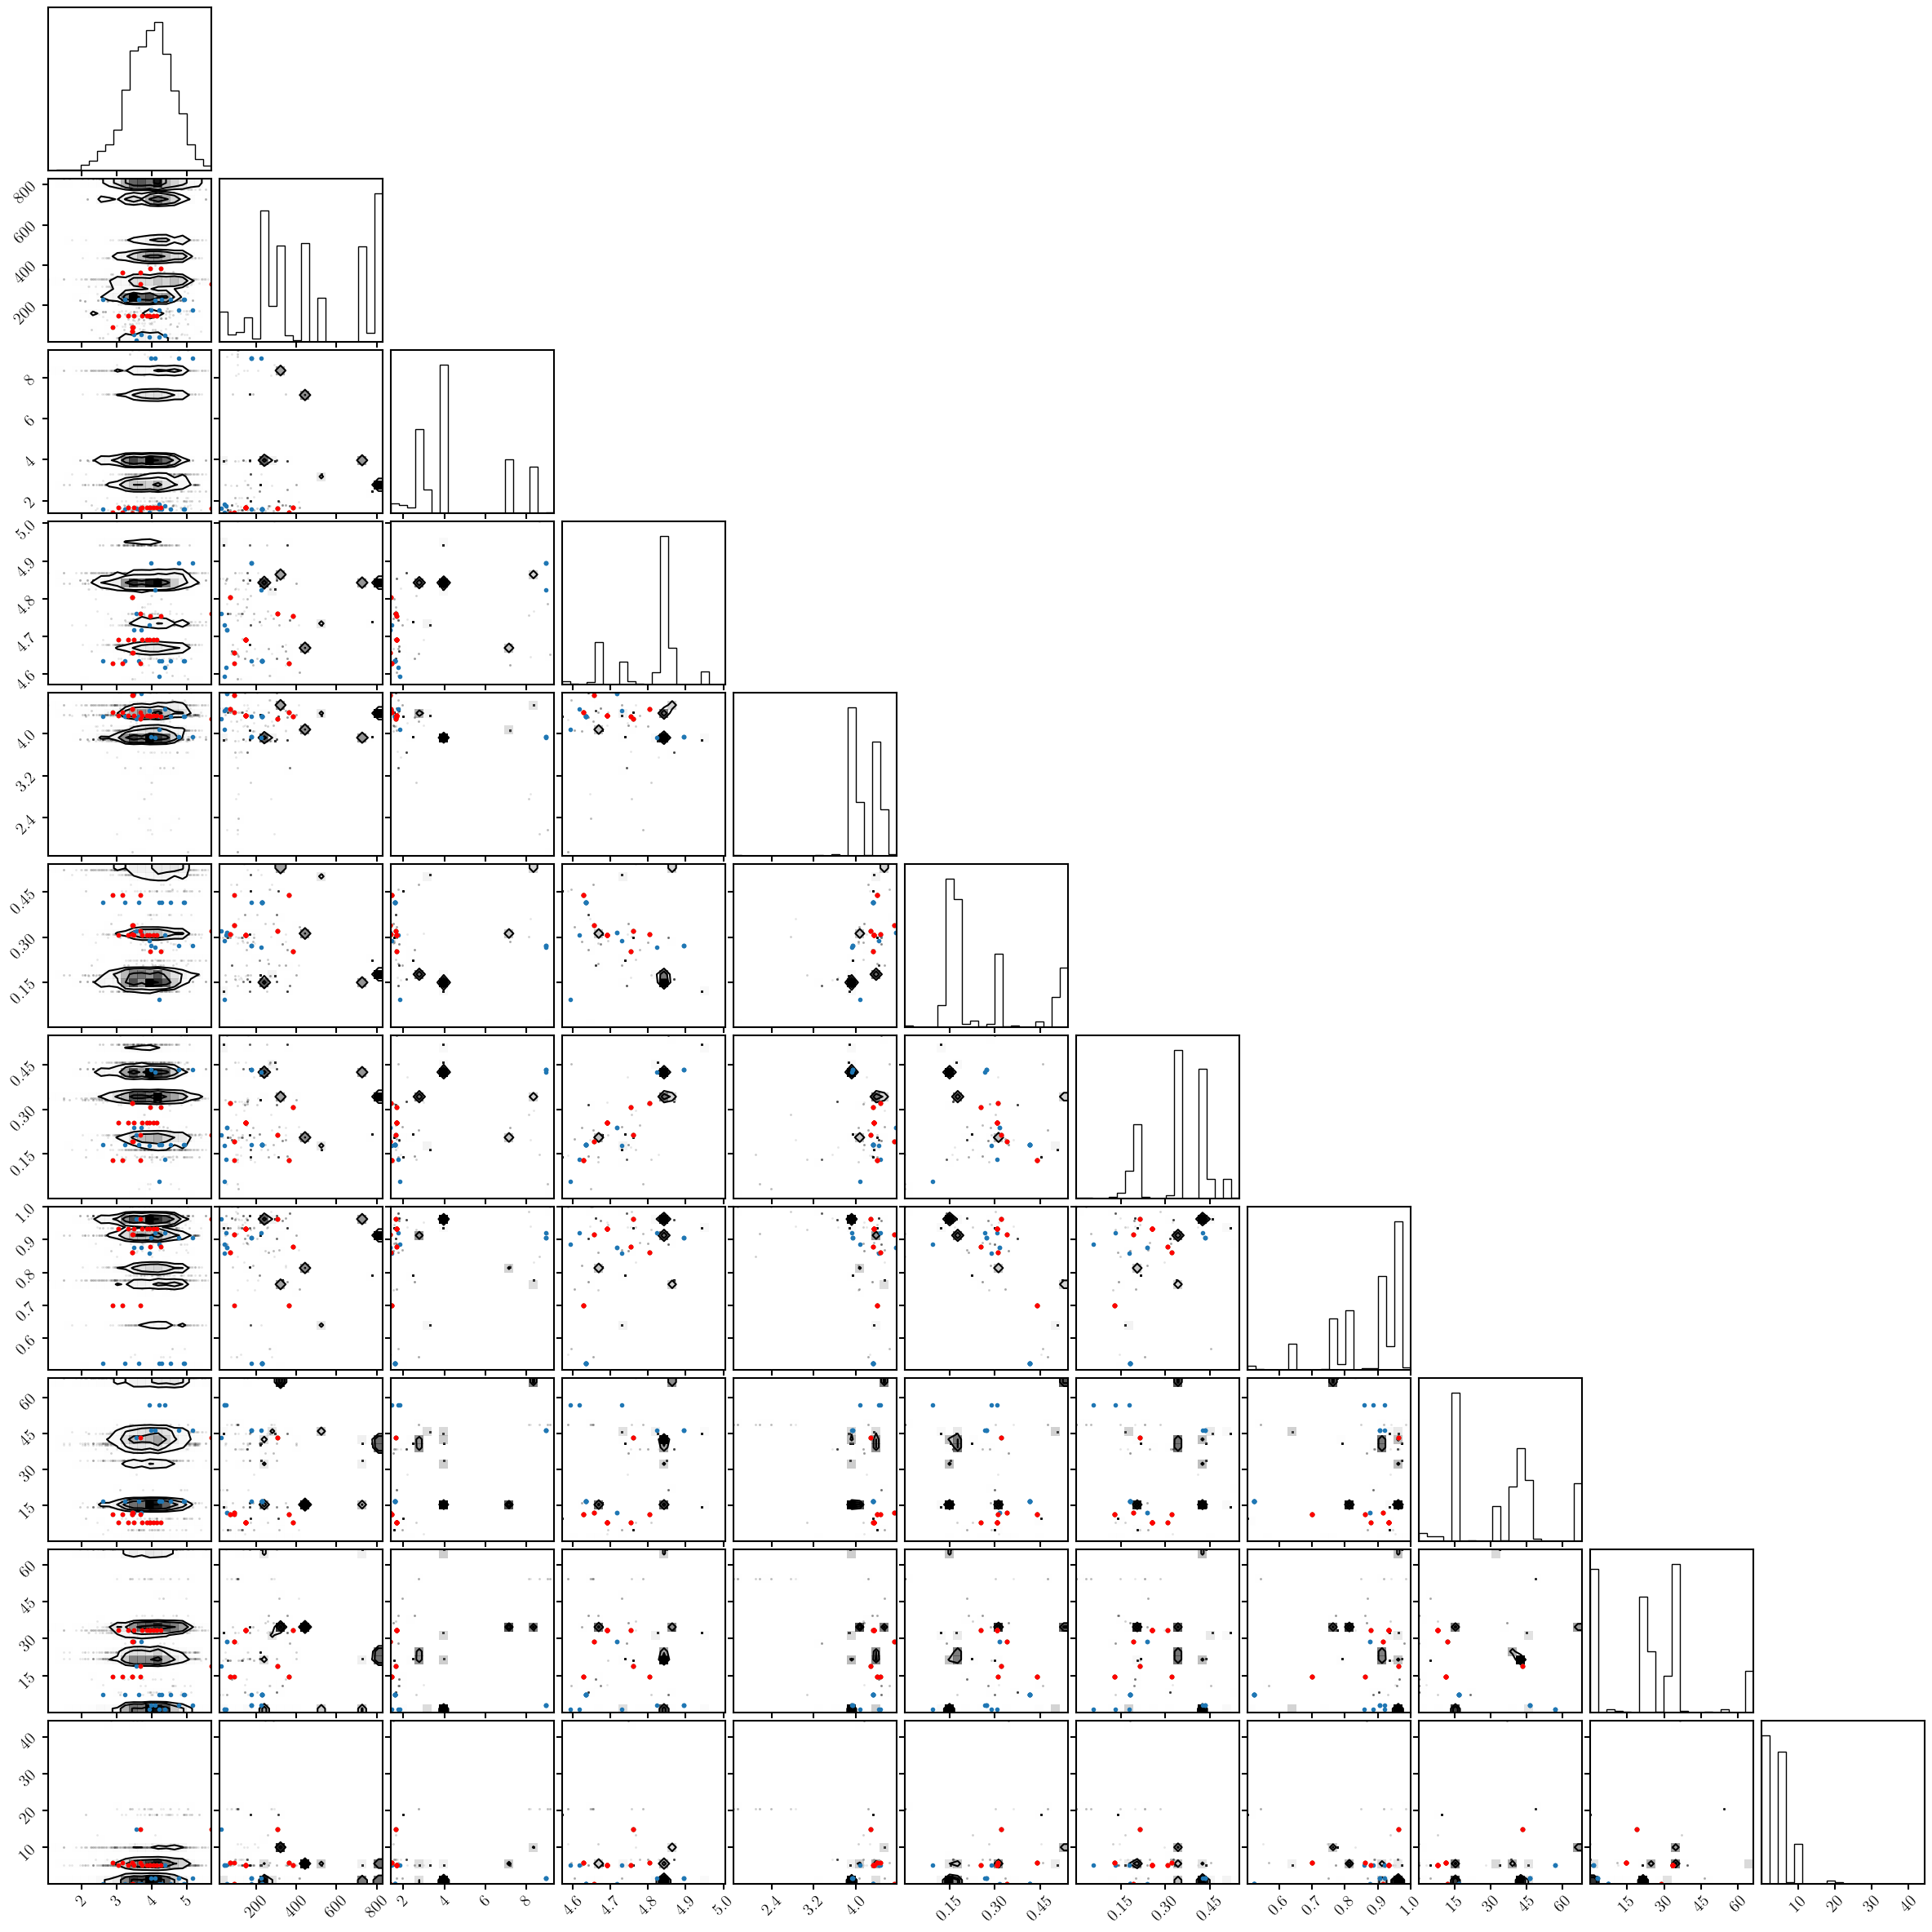

In [7]:
fig = DFM.corner(YX_micro[micro['binary_code'] == 0])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.95], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.8], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.5], color='r')

In [8]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-12915.24 \pm 4088.44 (37)
-14473.64 \pm 3117.07 (32)
-14549.27 \pm 5247.87 (29)
-14398.02 \pm 6490.71 (19)
-14398.02 \pm 6490.71 (19)


### c520

In [17]:
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/micro.0_2.hdf5')

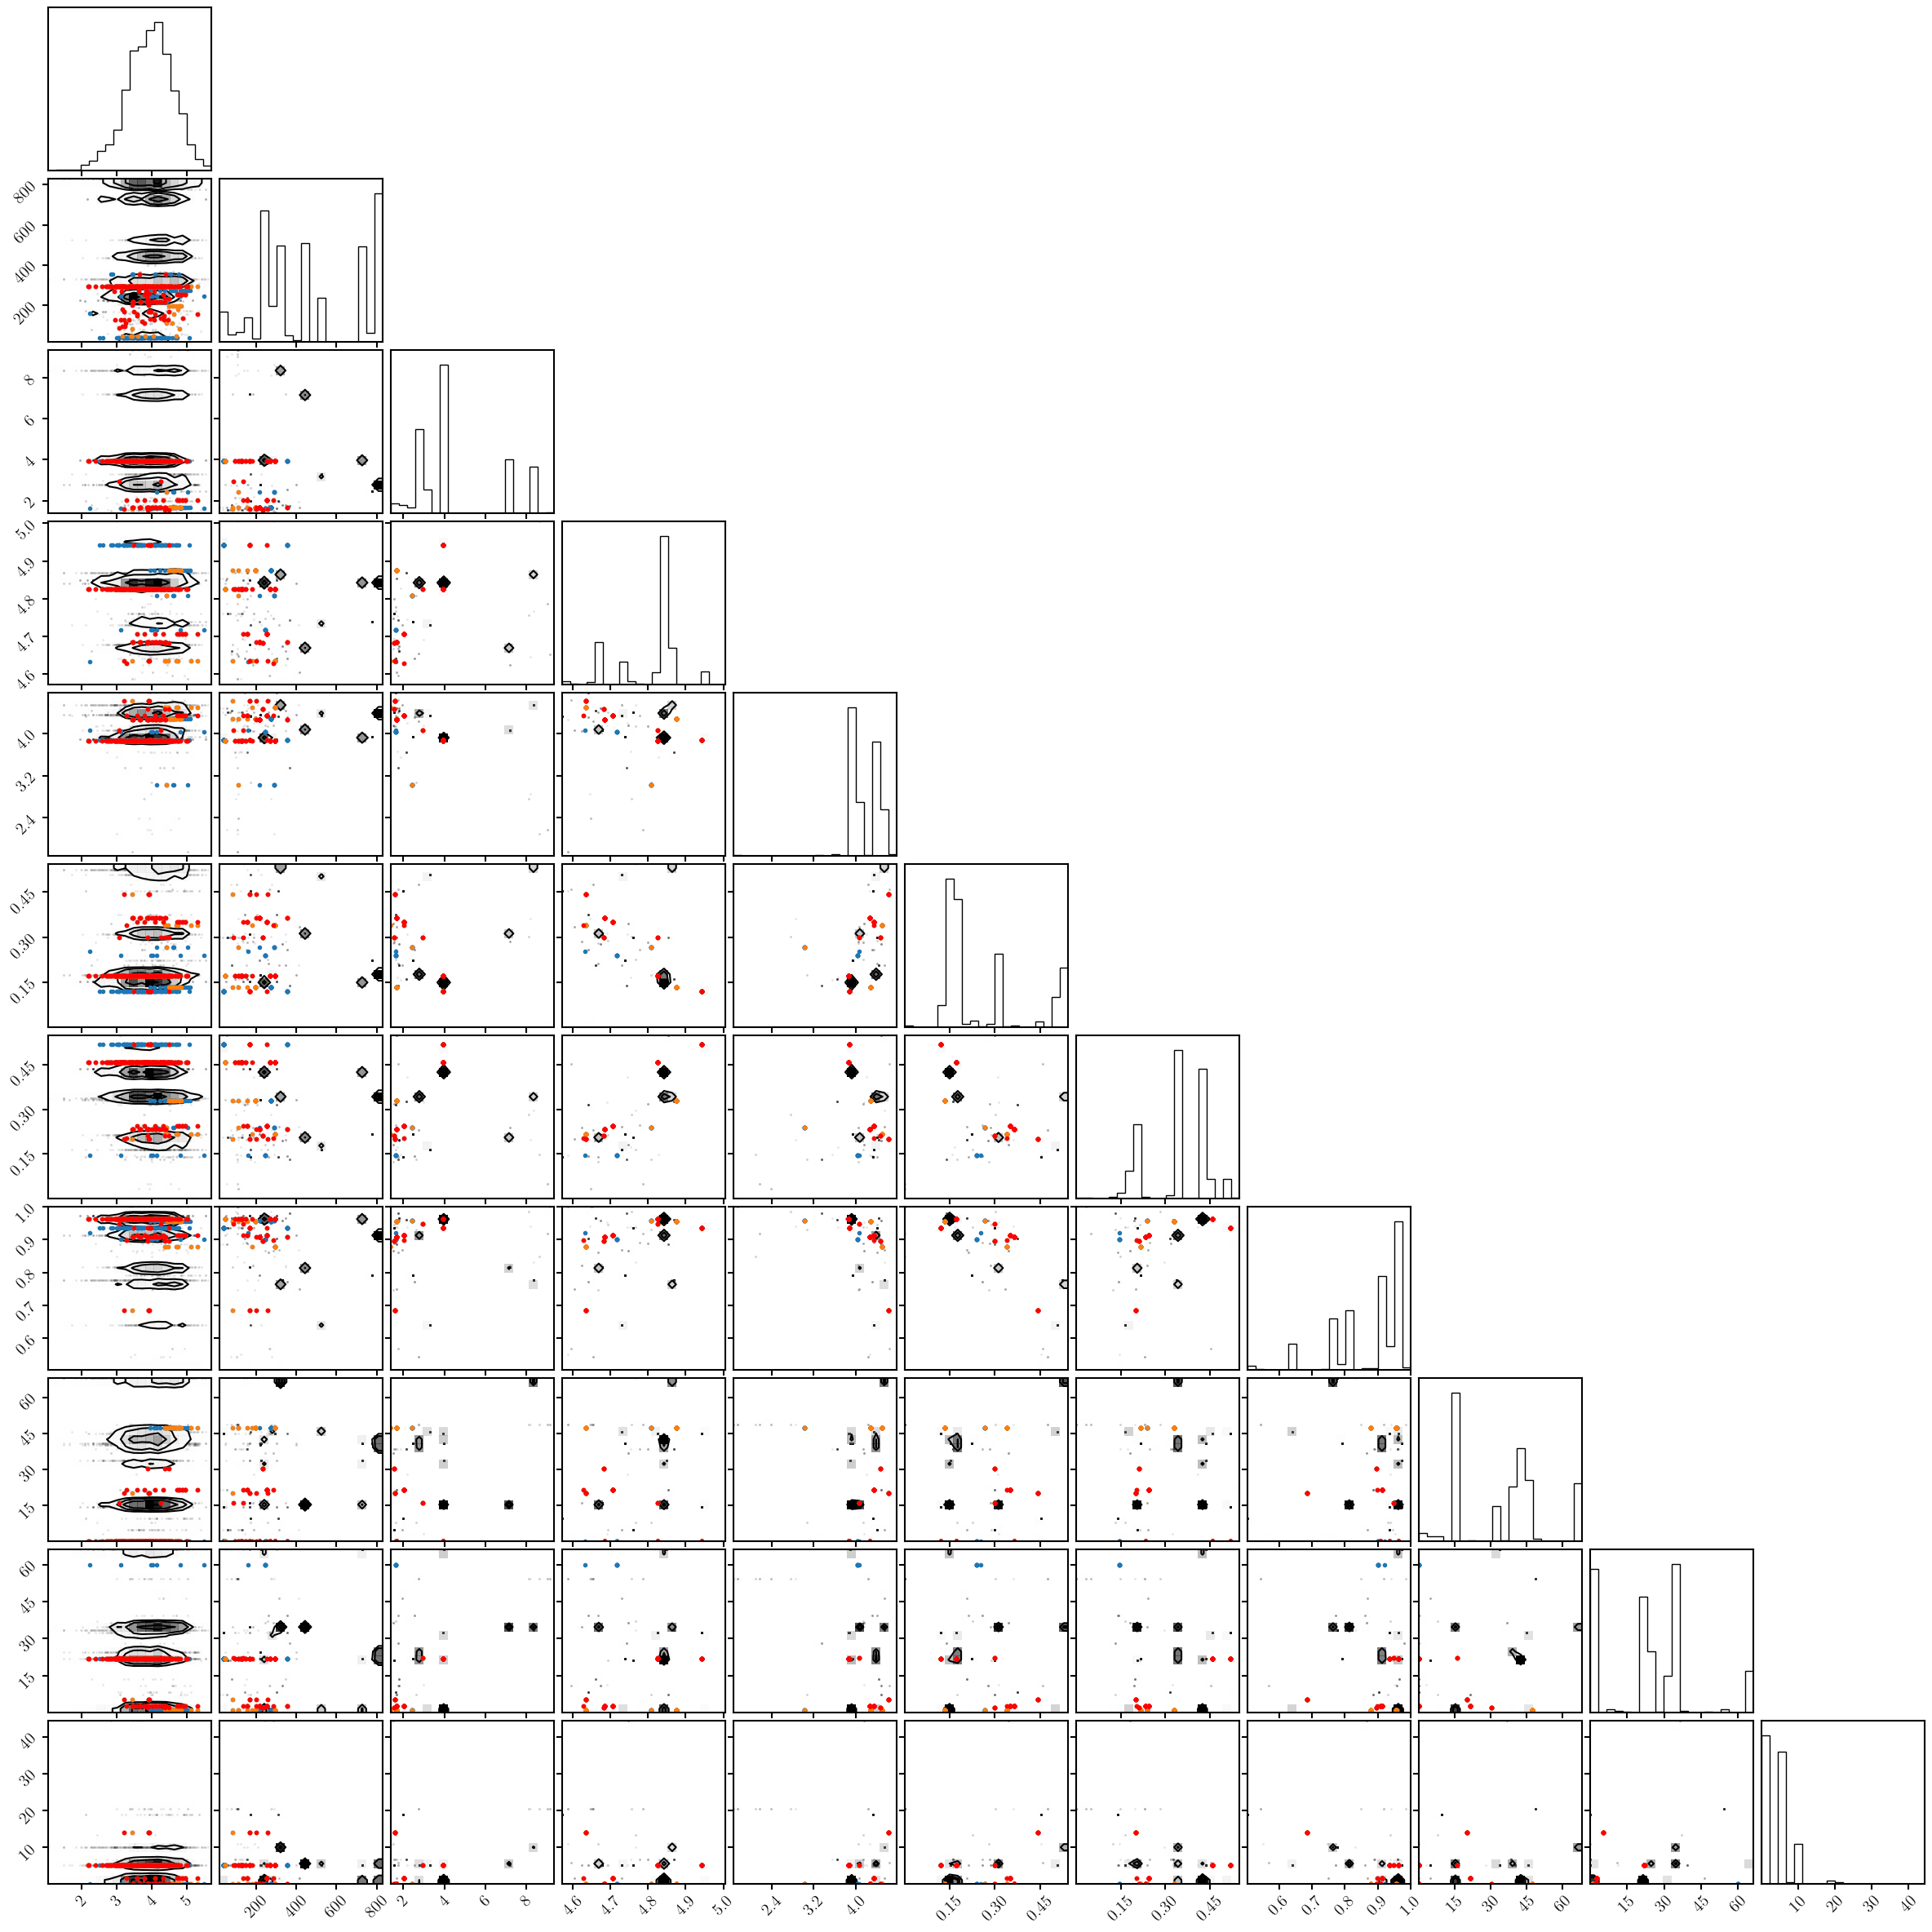

In [19]:
fig = DFM.corner(YX_micro[micro['binary_code'] == 0])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.95)], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.8)], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.5)], color='r')

In [20]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-6601.09 \pm 9623.61 (361)
-7176.93 \pm 7688.13 (340)
-7043.71 \pm 8218.41 (326)
-7127.48 \pm 7980.59 (254)
-7771.63 \pm 785.07 (227)


## c530

In [21]:
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/micro.0_4.hdf5')

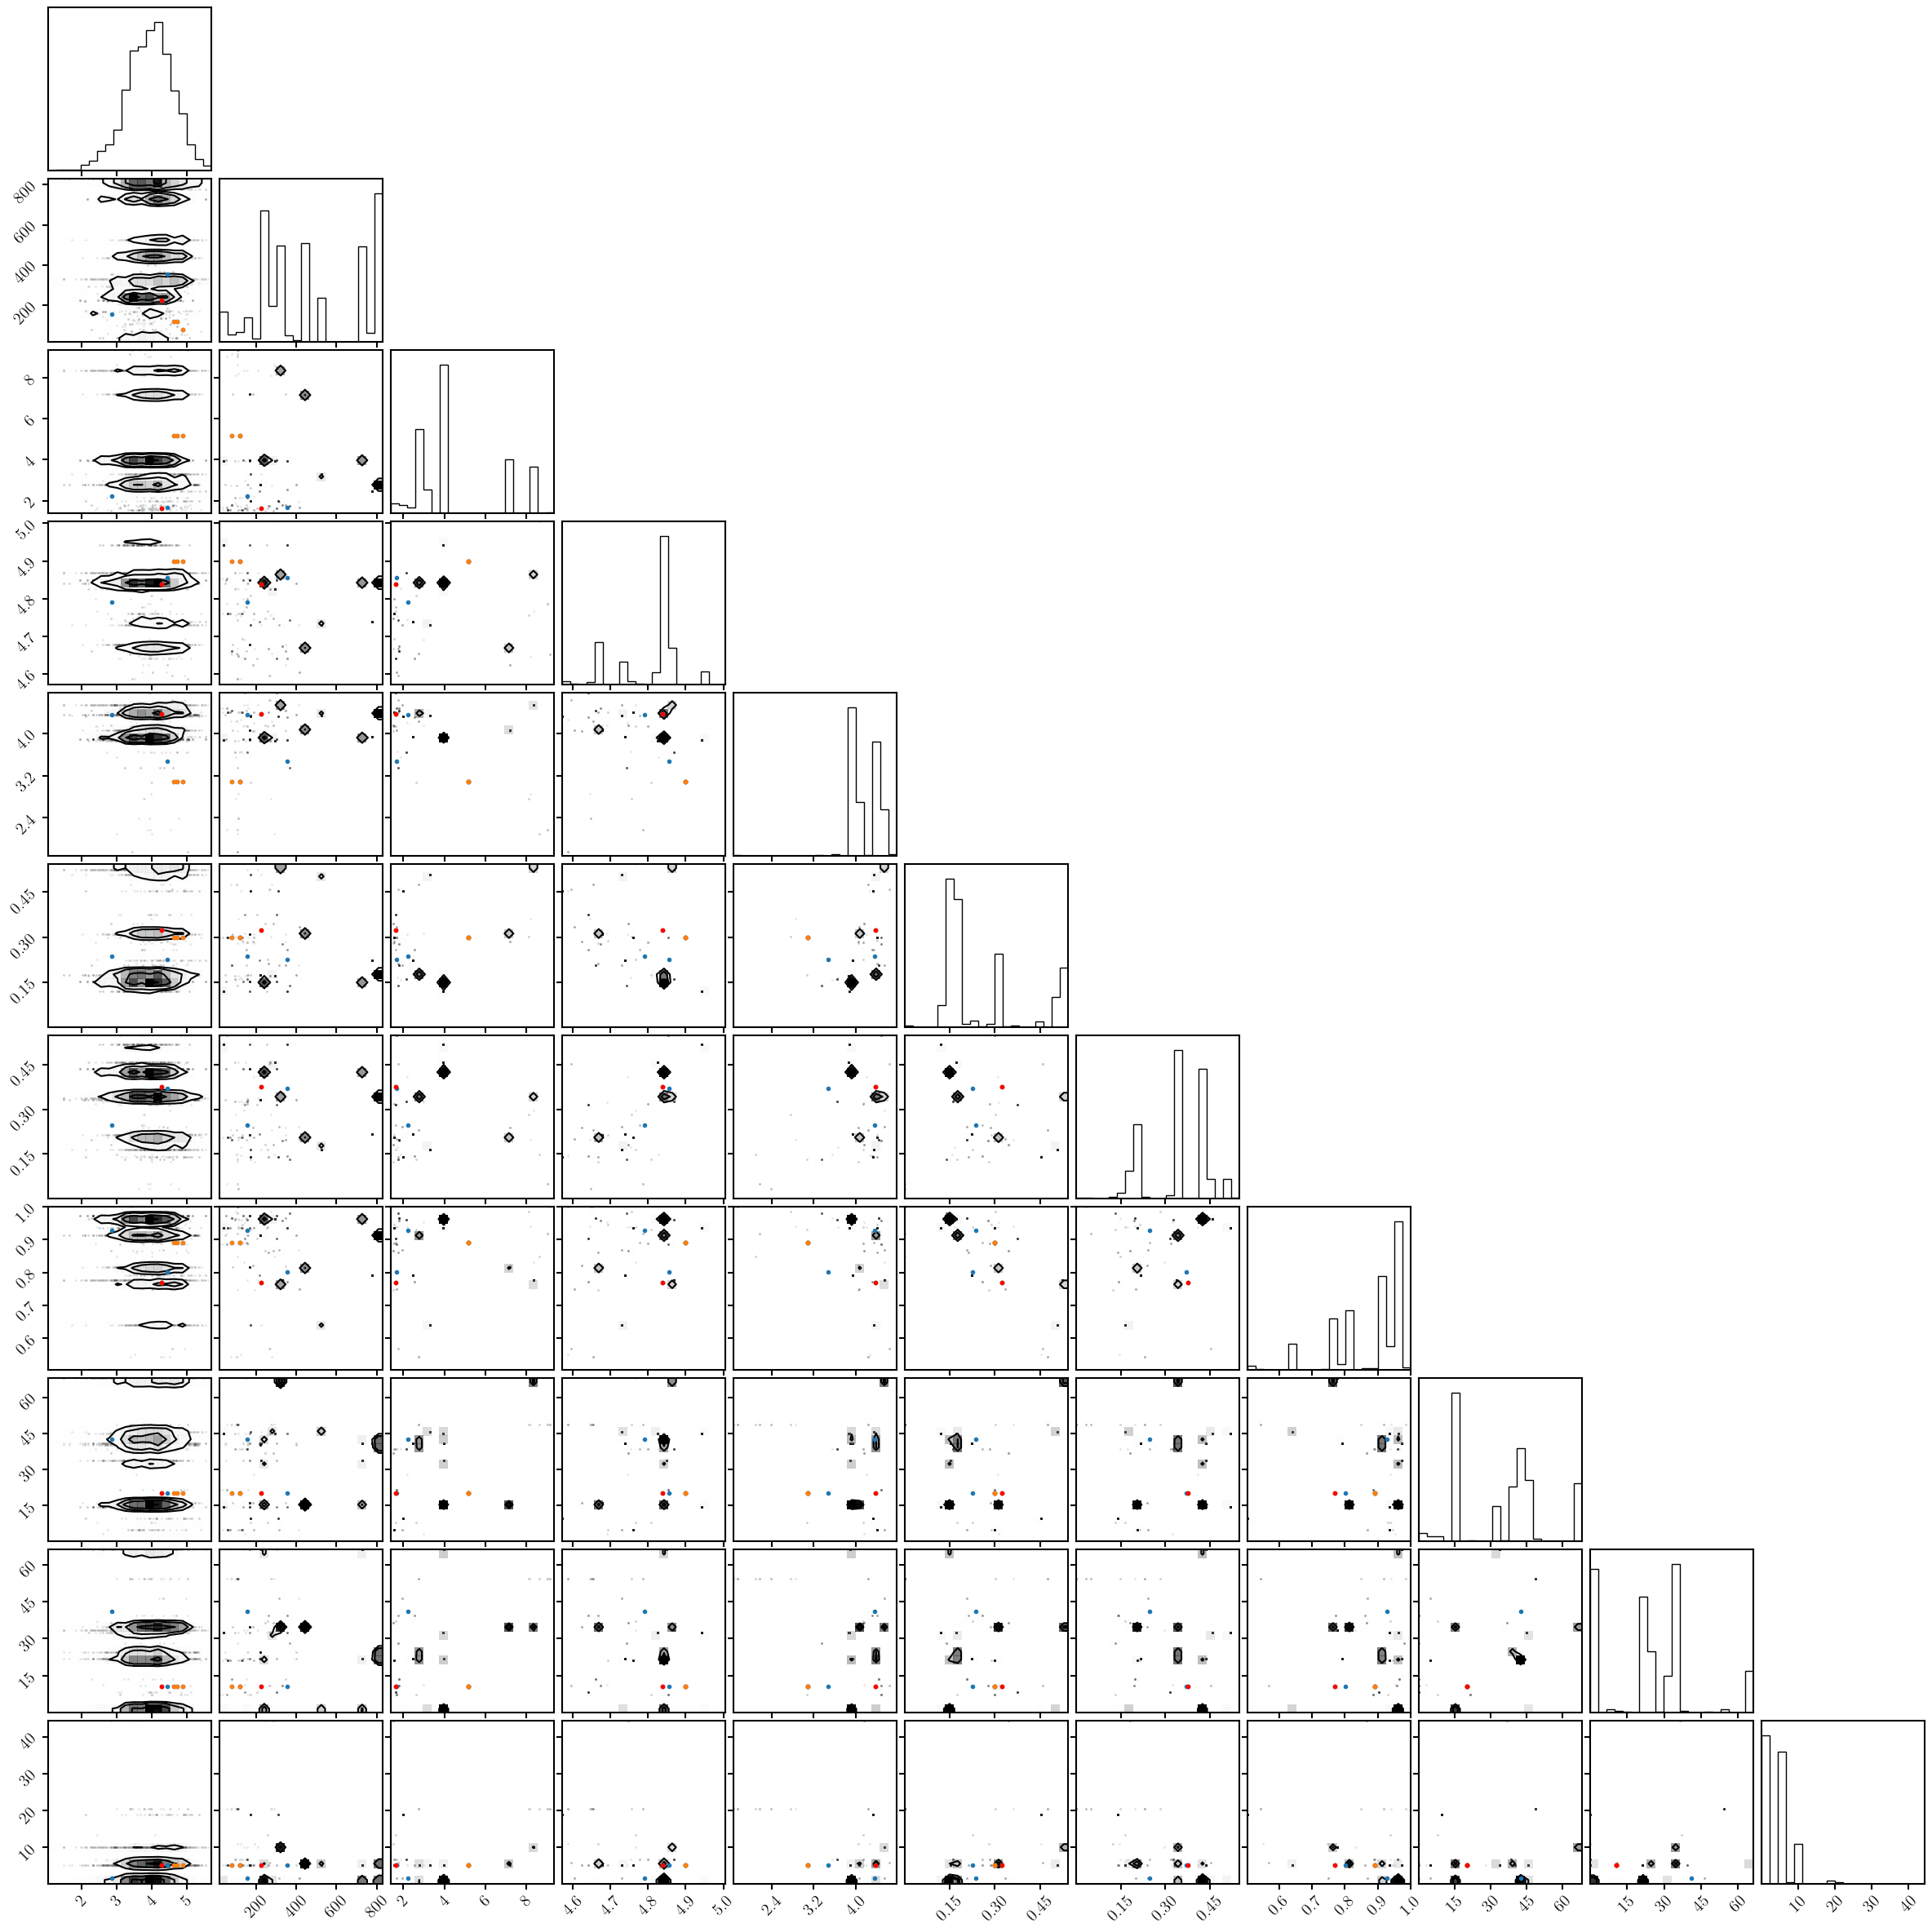

In [22]:
fig = DFM.corner(YX_micro[micro['binary_code'] == 0])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.95], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.8], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.5], color='r')

In [24]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh) & (exp_data['X_ref'][:,3] > 3.5)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-7406.11 \pm inf (2)
-7406.11 \pm inf (2)
-7406.11 \pm inf (2)
-1053.81 \pm inf (1)
-1053.81 \pm inf (1)


## c540

In [26]:
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/micro.0_8.hdf5')

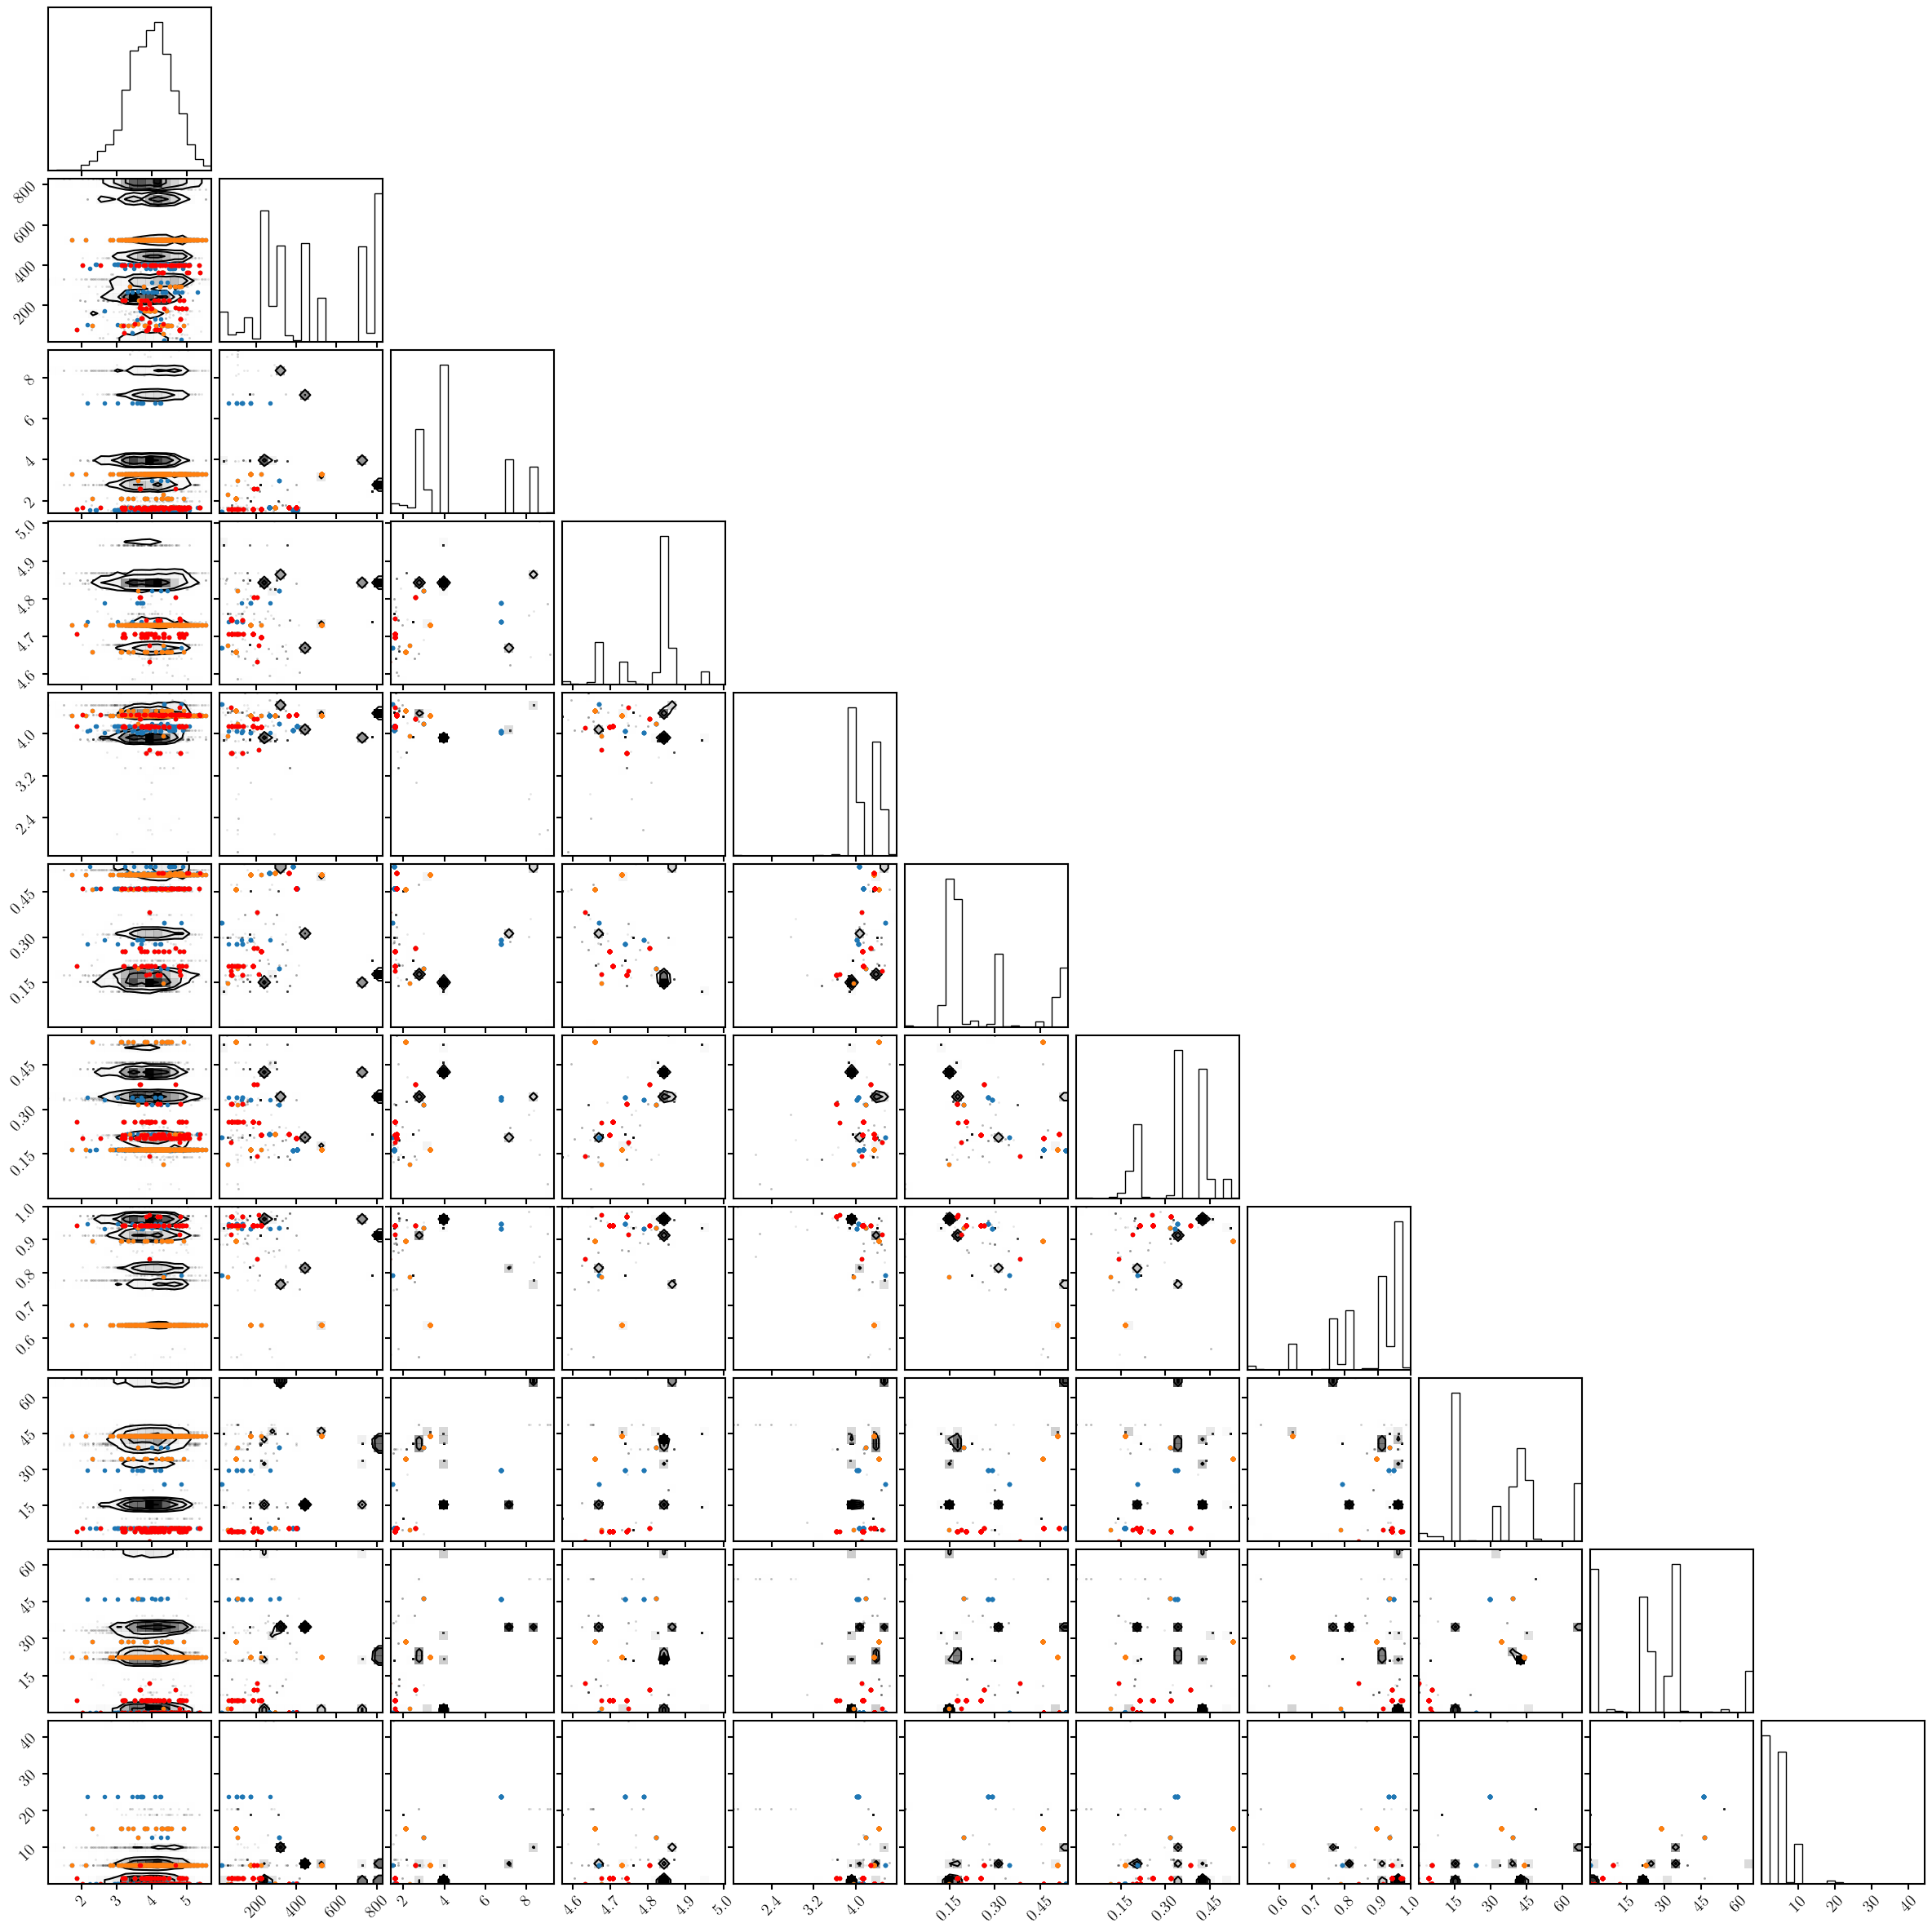

In [28]:
fig = DFM.corner(YX_micro[micro['binary_code'] == 0])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.95)], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.8)], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.5)], color='r')

In [29]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-25629.02 \pm 41149.28 (513)
-26152.26 \pm 41641.71 (506)
-18419.93 \pm 35291.09 (415)
-17894.79 \pm 24156.32 (384)
-15144.76 \pm 42459.95 (112)


## c610

In [31]:
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/micro.0_16.hdf5')

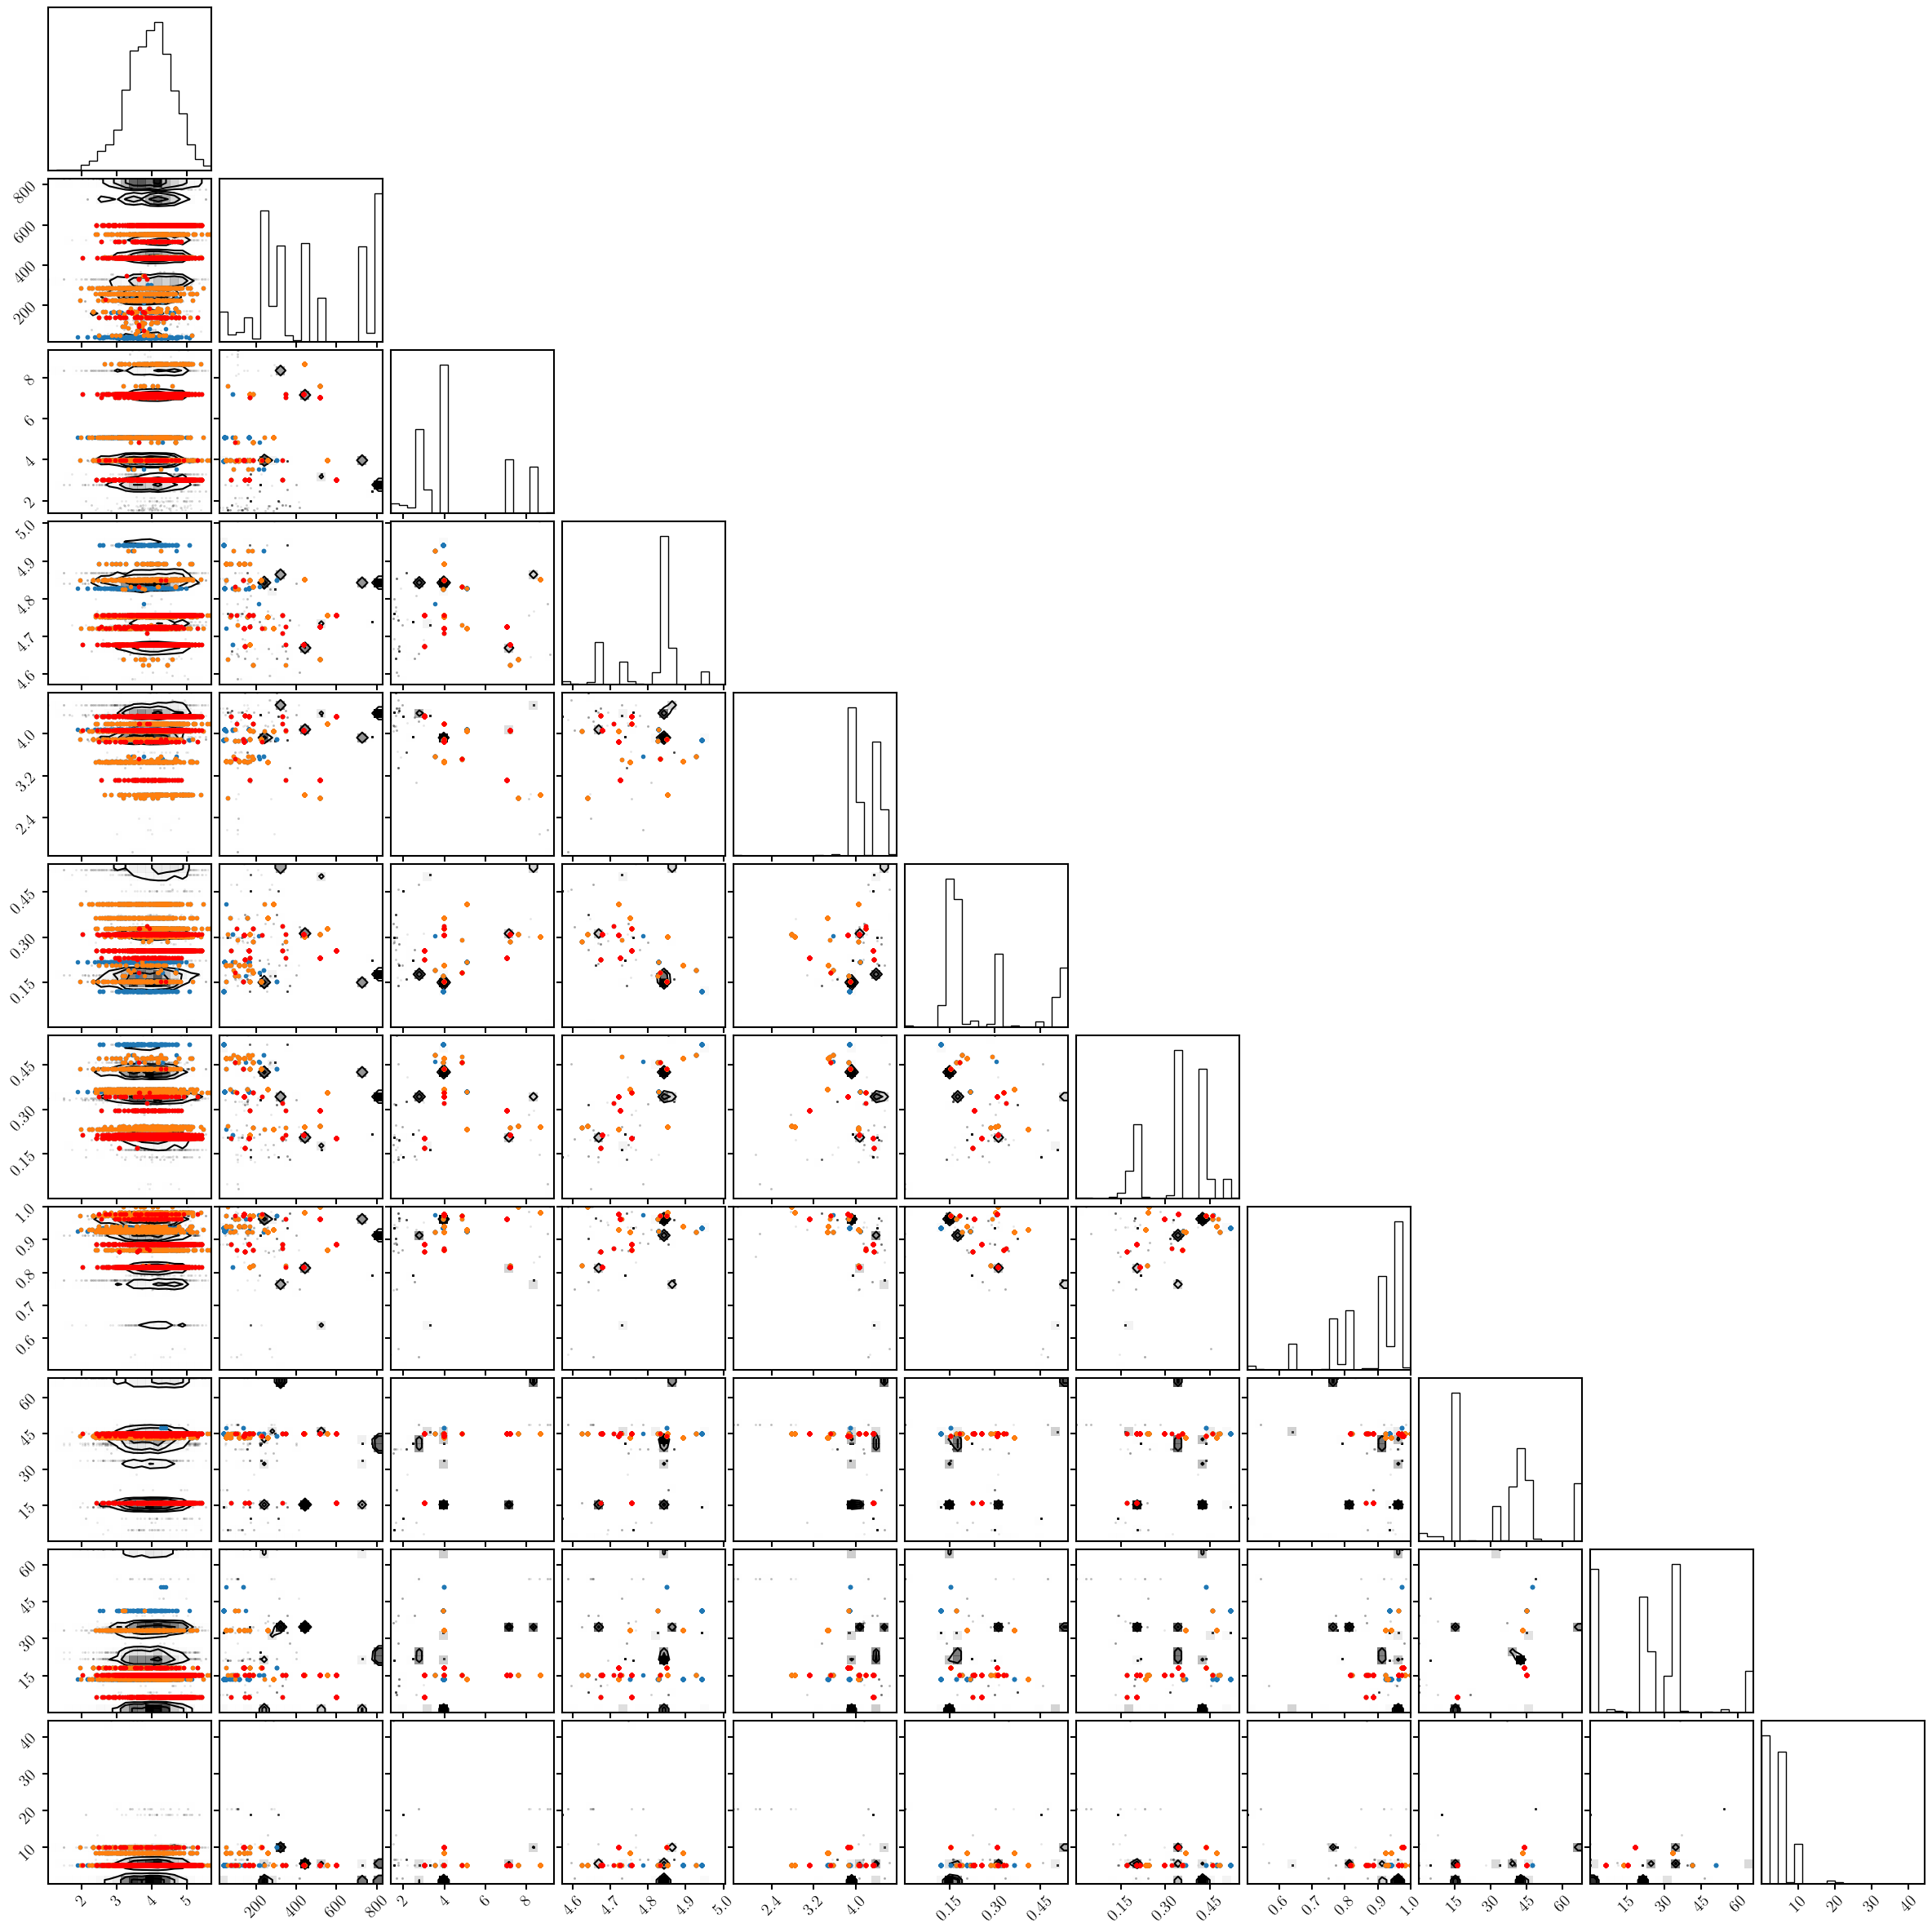

In [32]:
fig = DFM.corner(YX_micro[micro['binary_code'] == 0])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.95)], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.8)], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.5)], color='r')

In [33]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-9108.54 \pm 1950.97 (2339)
-8543.56 \pm 2482.36 (2046)
-8365.47 \pm 2604.67 (2007)
-8376.31 \pm 2627.85 (2002)
-7649.43 \pm 8987.97 (1141)


## c630

In [34]:
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/micro.0_64.hdf5')

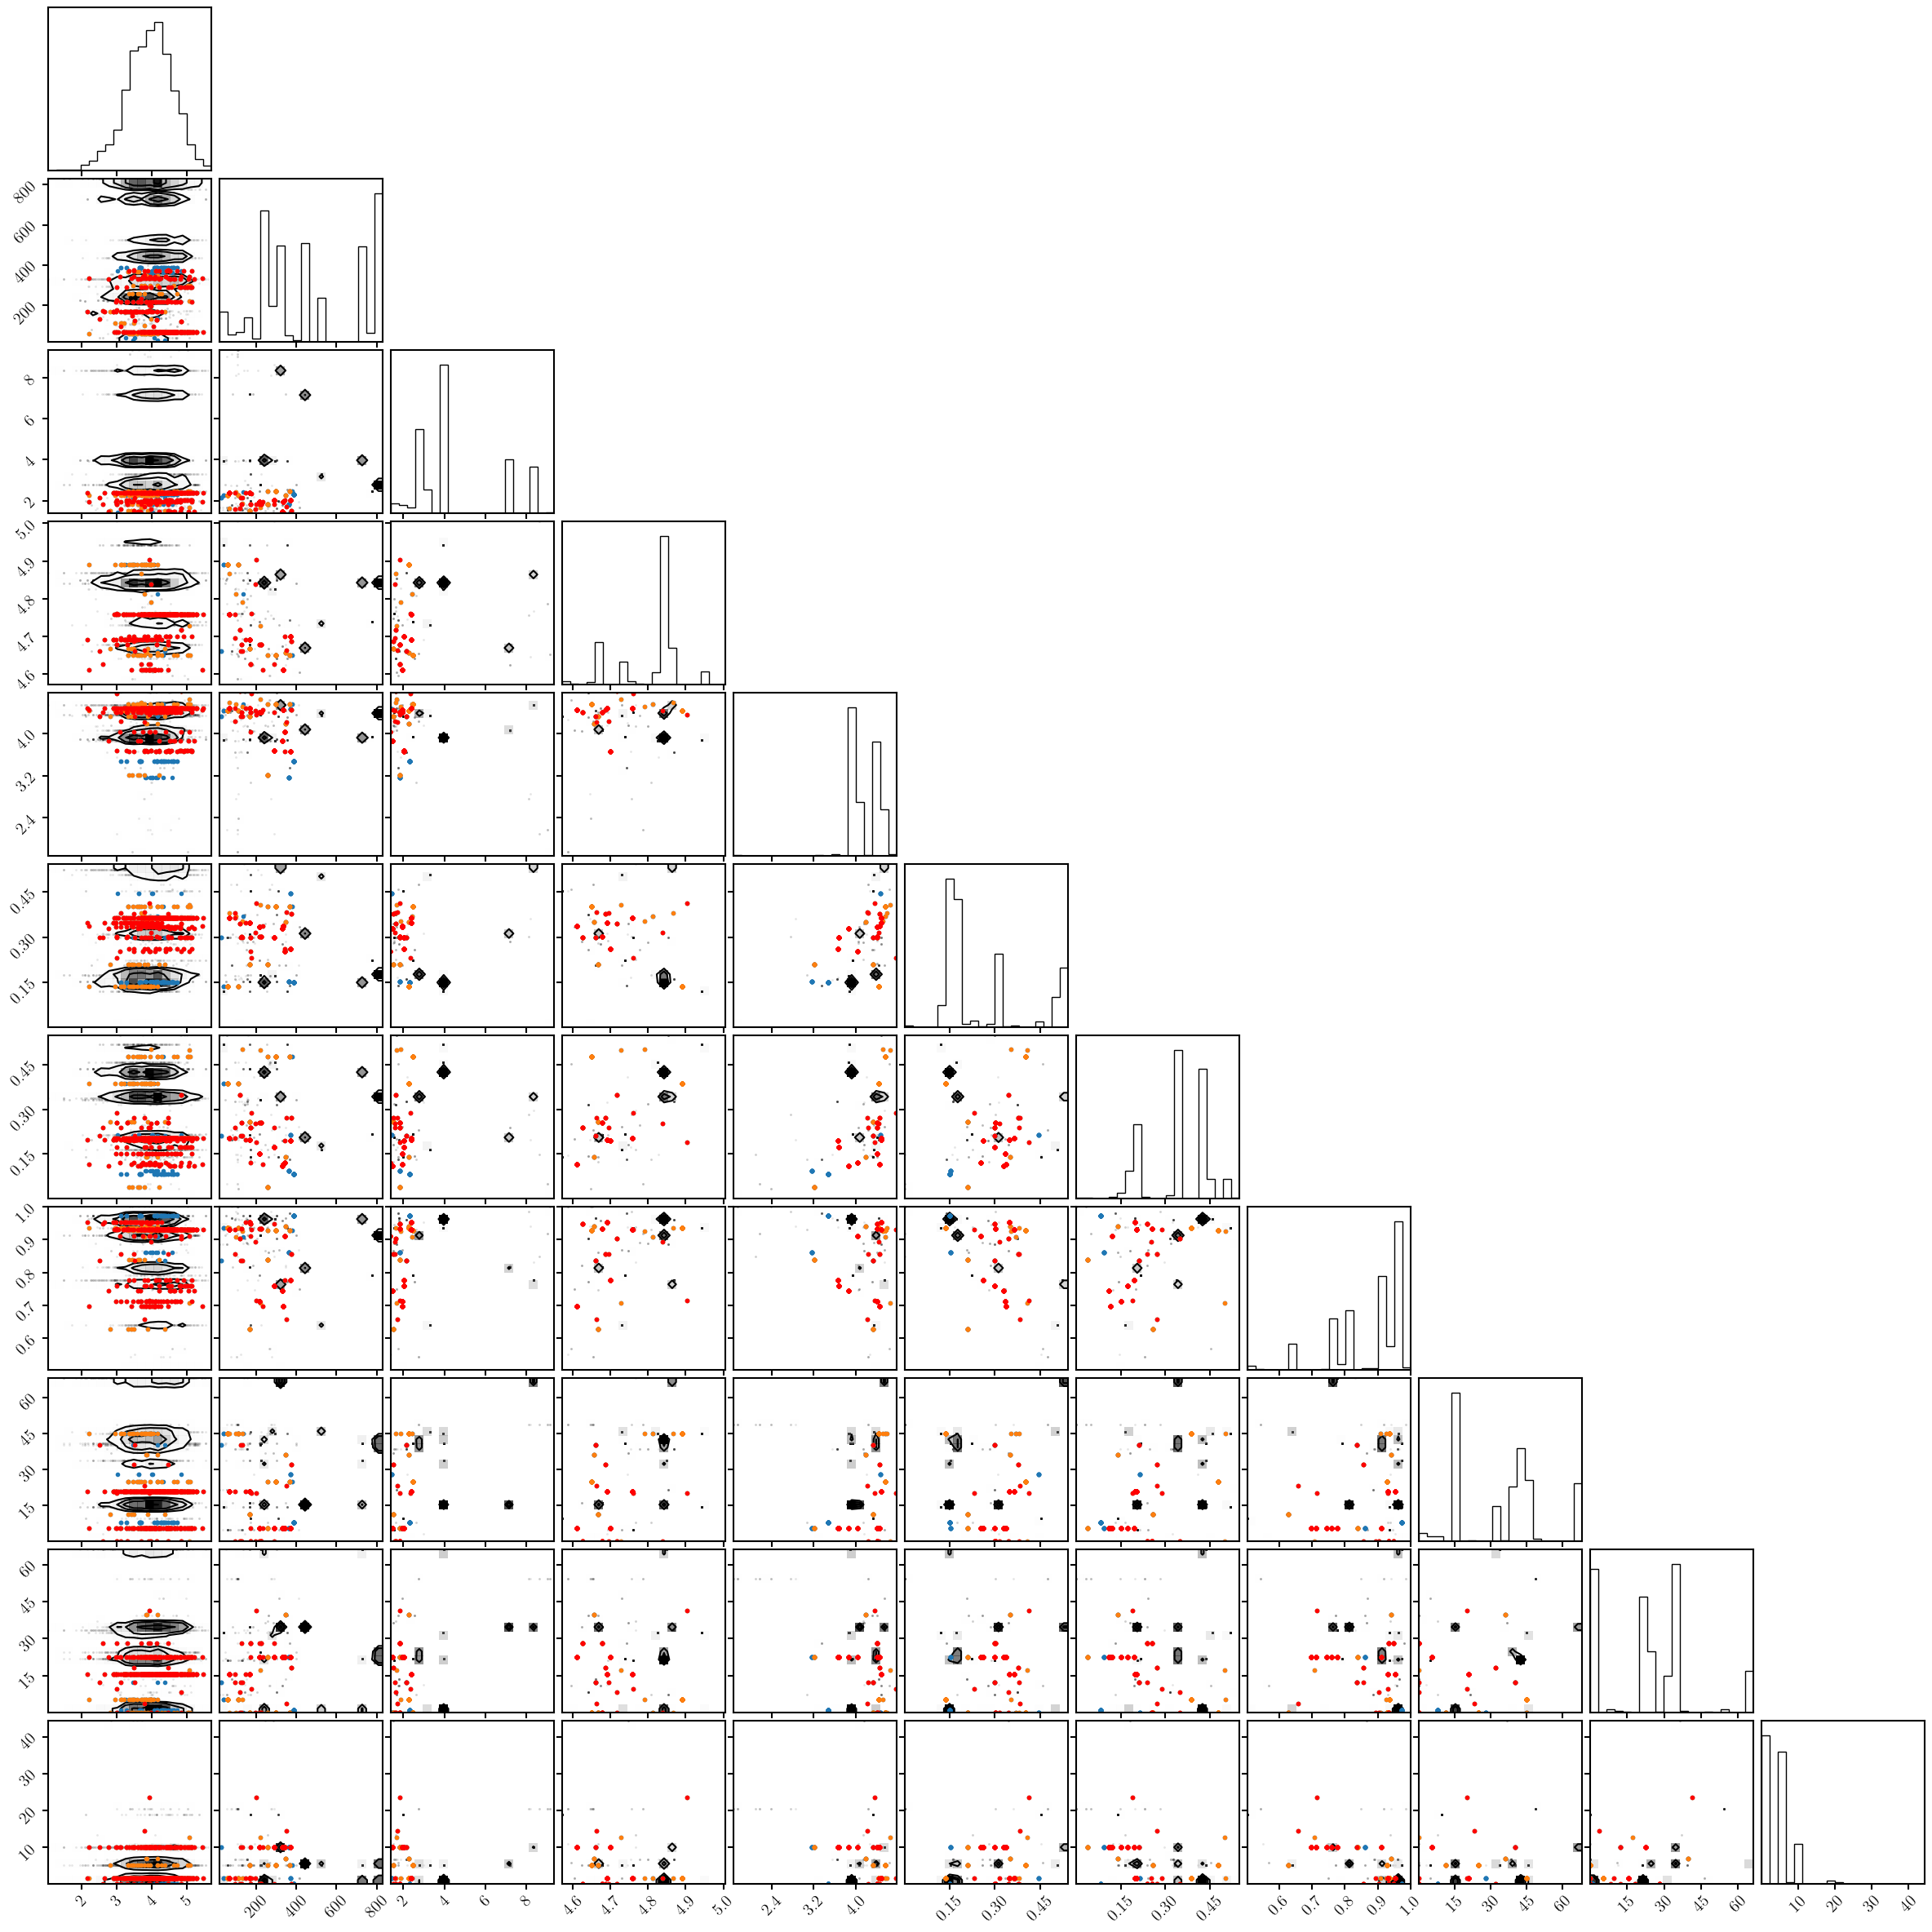

In [35]:
fig = DFM.corner(YX_micro[micro['binary_code'] == 0])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.95)], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.8)], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[(exp_data['p_support'] < 0.5)], color='r')

In [36]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-8325.14 \pm 6309.80 (475)
-8122.75 \pm 6577.79 (457)
-7603.21 \pm 7483.06 (416)
-7569.35 \pm 7844.78 (411)
-5845.36 \pm 11624.64 (351)
